In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import sctrial as st
pd.options.mode.chained_assignment = None


# Example: Vaccine Response Analysis (GSE171964)
### Dataset: BNT162b2 vaccination time course (GEO GSE171964)

**Background:** This notebook analyzes a real single-cell PBMC dataset collected across multiple post-vaccination days.

**Data Source:** GEO GSE171964 (barcodes, features, counts matrix, and phenotype metadata).

## 1. Load Actual Data


In [2]:
from pathlib import Path
import gzip
from scipy.io import mmread


def _resolve_dir_with_files(p: str, required_files) -> Path:
    path = Path(p)
    if path.is_absolute():
        if all((path / f).exists() for f in required_files):
            return path
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / path
        if all((cand / f).exists() for f in required_files):
            return cand
    return path


def load_vaccine_example_data(
    data_dir="data/vaccine_gse171964",
    processed_name="vaccine_gse171964_day0_day7.h5ad",
    max_participants=30,
    max_cells_per_group=200,
    seed=42,
):
    data_dir = _resolve_dir_with_files(
        data_dir,
        [
            "GSE171964_barcodes_v2.tsv.gz",
            "GSE171964_feats_v2.tsv.gz",
            "GSE171964_geo_pheno_v2.csv.gz",
            "GSE171964_countsmatrix_v2.mtx.gz",
        ],
    )
    processed_path = data_dir.parent / "processed" / processed_name

    if processed_path.exists():
        adata = sc.read_h5ad(processed_path)
        print(f"Loaded processed vaccine dataset (GSE171964): {adata.n_obs} cells, {adata.n_vars} genes")
        print("Processed file:", processed_path)
        print("Days:", adata.obs["day"].unique())
        print("Participants:", adata.obs["pt_id"].nunique())
        print("Cell types:", adata.obs["clustnm"].nunique())
        return adata

    barcodes_path = data_dir / "GSE171964_barcodes_v2.tsv.gz"
    feats_path = data_dir / "GSE171964_feats_v2.tsv.gz"
    pheno_path = data_dir / "GSE171964_geo_pheno_v2.csv.gz"
    mtx_path = data_dir / "GSE171964_countsmatrix_v2.mtx.gz"

    for p in [barcodes_path, feats_path, pheno_path, mtx_path]:
        if not p.exists():
            raise FileNotFoundError(f"Missing file: {p}")

    # Load barcodes and features
    barcodes = (
        pd.read_csv(barcodes_path, sep="\s+", header=None, engine="python", skiprows=1)[1]
        .astype(str)
        .str.strip('"')
        .tolist()
    )
    features = (
        pd.read_csv(feats_path, sep="\s+", header=None, engine="python", skiprows=1)[1]
        .astype(str)
        .str.strip('"')
        .tolist()
    )

    # Load count matrix
    with gzip.open(mtx_path, "rb") as f:
        X = mmread(f).tocsr()

    # Ensure shape is cells x genes
    if X.shape[0] == len(features) and X.shape[1] == len(barcodes):
        X = X.T
    elif X.shape[0] == len(barcodes) and X.shape[1] == len(features):
        pass
    else:
        raise ValueError("Matrix dimensions do not match barcodes/features.")

    adata = sc.AnnData(X=X)
    adata.obs_names = barcodes
    adata.var_names = features

    # Add phenotype metadata
    pheno = pd.read_csv(pheno_path)
    pheno["barcode"] = pheno["barcode"].astype(str)
    pheno = pheno.set_index("barcode")
    pheno = pheno.loc[adata.obs_names]
    adata.obs = pheno

    # Keep baseline and day 7 for a paired vaccine response
    adata = adata[adata.obs["day"].isin([0, 7])].copy()

    # Keep paired participants and cap participants
    paired = adata.obs.groupby("pt_id")["day"].nunique()
    keep_ids = paired[paired >= 2].index
    adata = adata[adata.obs["pt_id"].isin(keep_ids)].copy()

    rng = np.random.default_rng(seed)
    uniq_ids = adata.obs["pt_id"].unique()
    n = min(len(uniq_ids), max_participants)
    sel = rng.choice(uniq_ids, size=n, replace=False)
    adata = adata[adata.obs["pt_id"].isin(sel)].copy()

    # Cap cells per participant/day/celltype
    if max_cells_per_group is not None:
        grp = ["pt_id", "day", "clustnm"]
        sampled = (
            adata.obs.groupby(grp, observed=True, group_keys=False)
            .apply(lambda x: x.sample(min(len(x), max_cells_per_group), random_state=seed))
        )
        adata = adata[sampled.index].copy()

    # Add counts layer
    adata.layers["counts"] = adata.X.copy()

    processed_path.parent.mkdir(parents=True, exist_ok=True)
    adata.write_h5ad(processed_path)
    print("Saved processed file:", processed_path)

    print(f"Loaded vaccine dataset (GSE171964): {adata.n_obs} cells, {adata.n_vars} genes")
    print("Days:", adata.obs["day"].unique())
    print("Participants:", adata.obs["pt_id"].nunique())
    print("Cell types:", adata.obs["clustnm"].nunique())

    return adata

adata = load_vaccine_example_data()


Loaded processed vaccine dataset (GSE171964): 21331 cells, 20102 genes
Processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/vaccine_gse171964_day0_day7.h5ad
Days: [0 7]
Participants: 6
Cell types: 18


## 2. Analysis


Paired participants (0 vs 7): 6


Within-arm (participant_visit, standardized):


,beta_time,p_time,n_units,FDR_time
feature,,,,
ms_B_Cell_Response,-0.328167,0.731723,6,0.958162
ms_IFN_Signature,0.745510,0.199715,6,0.599144
ms_Inflammatory,-0.055257,0.958162,6,0.958162


Within-arm (cell-level, raw):


,beta_time,p_time,n_units,FDR_time
feature,,,,
ms_B_Cell_Response,-0.072536,0.437051,6,0.437051
ms_IFN_Signature,0.195660,0.000012,6,0.000036
ms_Inflammatory,-0.659615,0.097073,6,0.145610


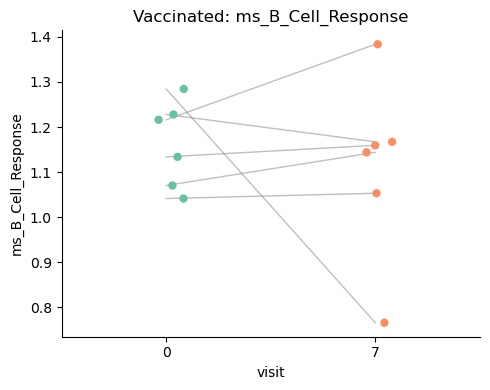

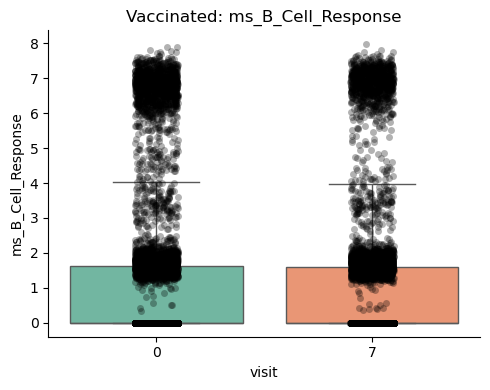

In [3]:
available = set(adata.var_names)
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

gene_sets = {
    "B_Cell_Response": [g for g in ["CD79A", "CD79B", "MS4A1"] if g in available],
    "IFN_Signature": [g for g in ["ISG15", "IFI6", "MX1"] if g in available],
    "Inflammatory": [g for g in ["S100A8", "S100A9", "LYZ"] if g in available]
}

gene_sets = {k: v for k, v in gene_sets.items() if len(v) >= 3}
if gene_sets:
    adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="mean", prefix="ms_")
else:
    print("No gene sets matched this dataset; skipping module scoring.")

# Standardize metadata for trial analysis
adata.obs["visit"] = adata.obs["day"].astype(str)
adata.obs["participant_id"] = adata.obs["pt_id"].astype(str)
adata.obs["arm"] = "Vaccinated"
adata.obs["cell_type"] = adata.obs["clustnm"].astype(str)

design = st.TrialDesign(
    participant_col="participant_id",
    visit_col="visit",
    arm_col="arm",
    arm_treated="Vaccinated",
    arm_control="Vaccinated",
    celltype_col="cell_type",
)

features = [c for c in adata.obs.columns if c.startswith("ms_")]
paired = adata.obs.groupby("participant_id")["visit"].nunique()
n_paired = int((paired >= 2).sum())
print(f"Paired participants (0 vs 7): {n_paired}")

if not features:
    print("No module scores available; skipping within-arm analysis.")
elif n_paired < 4:
    print("Within-arm analysis requires at least 4 paired participants; skipping.")
else:
    # Within-arm comparison (participant_visit)
    res = st.within_arm_comparison(
        adata,
        arm="Vaccinated",
        features=features,
        design=design,
        visits=("0", "7"),
        aggregate="participant_visit",
        standardize=True,
    )
    print("Within-arm (participant_visit, standardized):")
    if not res.empty:
        display(res.set_index("feature"))

    # Within-arm comparison (cell-level, raw)
    res_cell = st.within_arm_comparison(
        adata,
        arm="Vaccinated",
        features=features,
        design=design,
        visits=("0", "7"),
        aggregate="cell",
        standardize=False,
    )
    print("Within-arm (cell-level, raw):")
    if not res_cell.empty:
        display(res_cell.set_index("feature"))

    # Plots (single-arm, so skip multi-arm interaction)
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata,
        arm="Vaccinated",
        feature=features[0],
        design=design,
        visits=("0", "7"),
        plot_type="paired",
        ax=ax,
    )
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata,
        arm="Vaccinated",
        feature=features[0],
        design=design,
        visits=("0", "7"),
        plot_type="box",
        ax=ax,
    )
    plt.tight_layout(); plt.show()
